## primero descargamos los datos

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

## head()
usamos head() para mostrar las primeras 5 filas de los datos del dataframe

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## info()
con info() obtenemos una descripcion rapido de los datos

In [4]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## value_counts()
que categorias existen y cuantos de los datos pertenecen a esas categorias

In [5]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## describe()
muestra un resumen de los atributos numericos

In [6]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


usamos matplotlib para graficar un histograma de cada atributo numerico

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

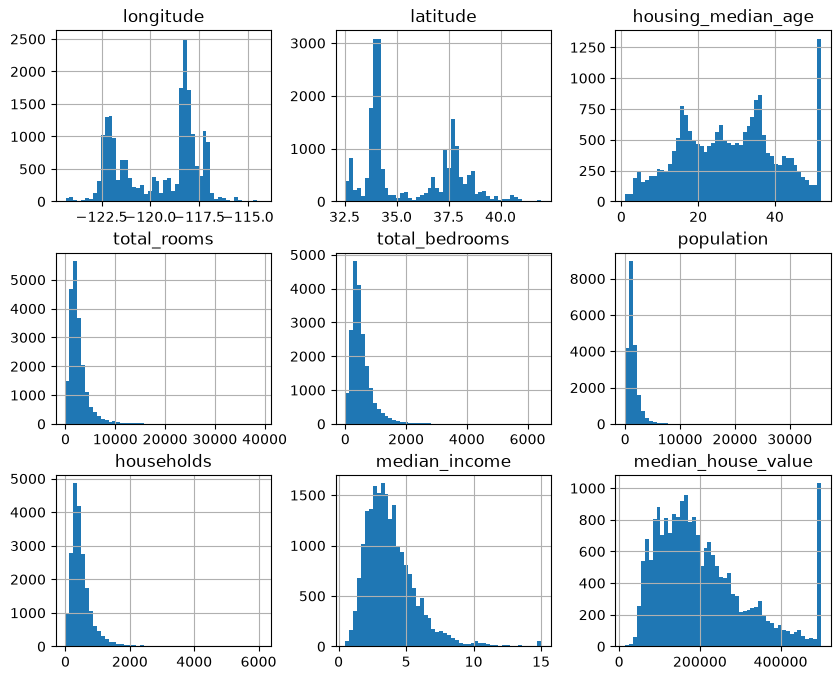

In [7]:
import matplotlib.pyplot as plt

housing_full.hist(bins=50,figsize=(10,8))

creo una columna de categorias

In [ ]:
import numpy as np

# 1. Creamos rangos de precios (por ejemplo, de 1 a 5)
housing_full["income_cat"] = pd.cut(
    housing_full["median_house_value"],
    bins=[0.0, 100000, 200000, 300000, 400000, np.inf],
    labels=[1, 2, 3, 4, 5],
)

separamos los datos en entrenamiento y prueba

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split( housing_full,test_size=0.2, random_state=42,stratify=housing_full["income_cat"])#usamos stratify para mantener la misma proporcion de clases en ambos grupos


borramos la columna que creamos para dejar los datos limpios

In [10]:
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

guardo una copia de los datos de entrenamiento

In [11]:
housing=train_set.copy()

## vemos los datos geograficamente

<function matplotlib.pyplot.show(close=None, block=None)>

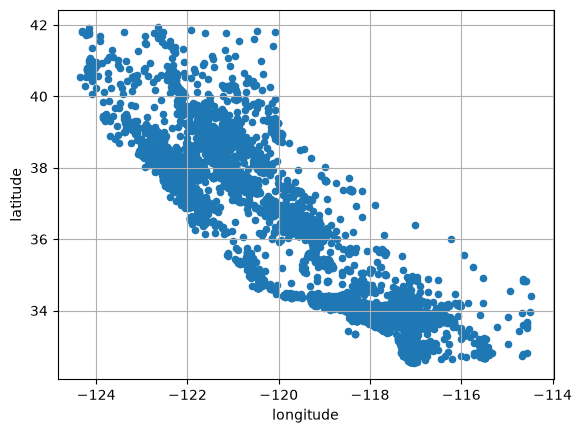

In [12]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

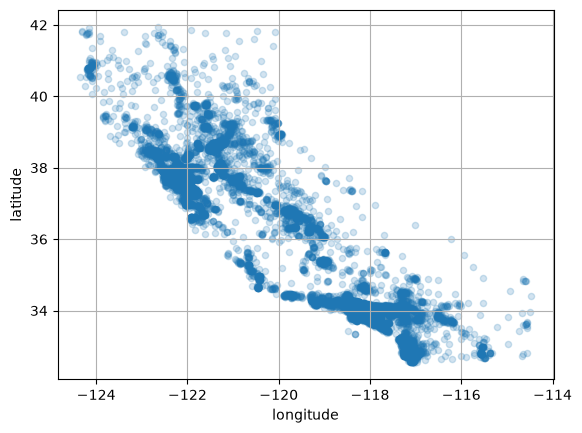

In [13]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2)
plt.show

# Buscamos correlaciones

In [14]:
corr_matrix=housing.corr(numeric_only=True)

In [16]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.692189
total_rooms           0.140293
housing_median_age    0.105336
households            0.072086
total_bedrooms        0.055845
population           -0.019025
longitude            -0.051078
latitude             -0.139836
Name: median_house_value, dtype: float64